In [2]:
import sys, pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecNormalize

from procs.stochastic_processes import (
    MarketReplayMidpriceModel, PoissonArrivalModel, ExponentialFillFunction,
)
from procs.gym.model_dynamics import LimitOrderModelDynamics
from procs.gym.trading_environment import TradingEnvironment
from procs.gym.sb3_wrapper import StableBaselinesTradingEnvironment
from procs.rewards import PnLReward, CjMmDrawdownPenalty
from procs.agents import AvellanedaStoikovAgent, Sb3Agent
from procs.gym.helpers.plotting import plot_trajectory, plot_learned_policy
from procs.gym.helpers.generate_trajectory_stats import generate_trajectory_stats
from procs.gym.helpers.fast_rollout import fast_simulate
from procs.gym.data_loader import load_single_day
from procs.gym.calibration import tune_gamma
from procs.gym.features import FeatureComputer, RollingVolatility
from procs.gym.reward_scale import estimate_reward_scale

%matplotlib inline


In [3]:
DATA_PATH = r"C:\Users\john-\Documents\Thesis_AI4T\datasets\binance_book_snapshot_25_2025-01-01_DOGEUSDT.csv"
S, dt_sec, dt_index = load_single_day(DATA_PATH)
T_sec = float(dt_sec.sum())
sigma = MarketReplayMidpriceModel(S, dt_sec).volatility
print(f"Loaded {len(S):,} snapshots, σ={sigma:.6f}, T={T_sec:.0f}s")

Loaded 713,815 snapshots, σ=0.000021, T=86398s


In [4]:
kappa, A, tick, Q_MAX = 35_000, 0.8, 0.00001, 50

c:\Users\john-\Documents\Thesis_AI4T\procs\gym\helpers\plotting.py:155: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


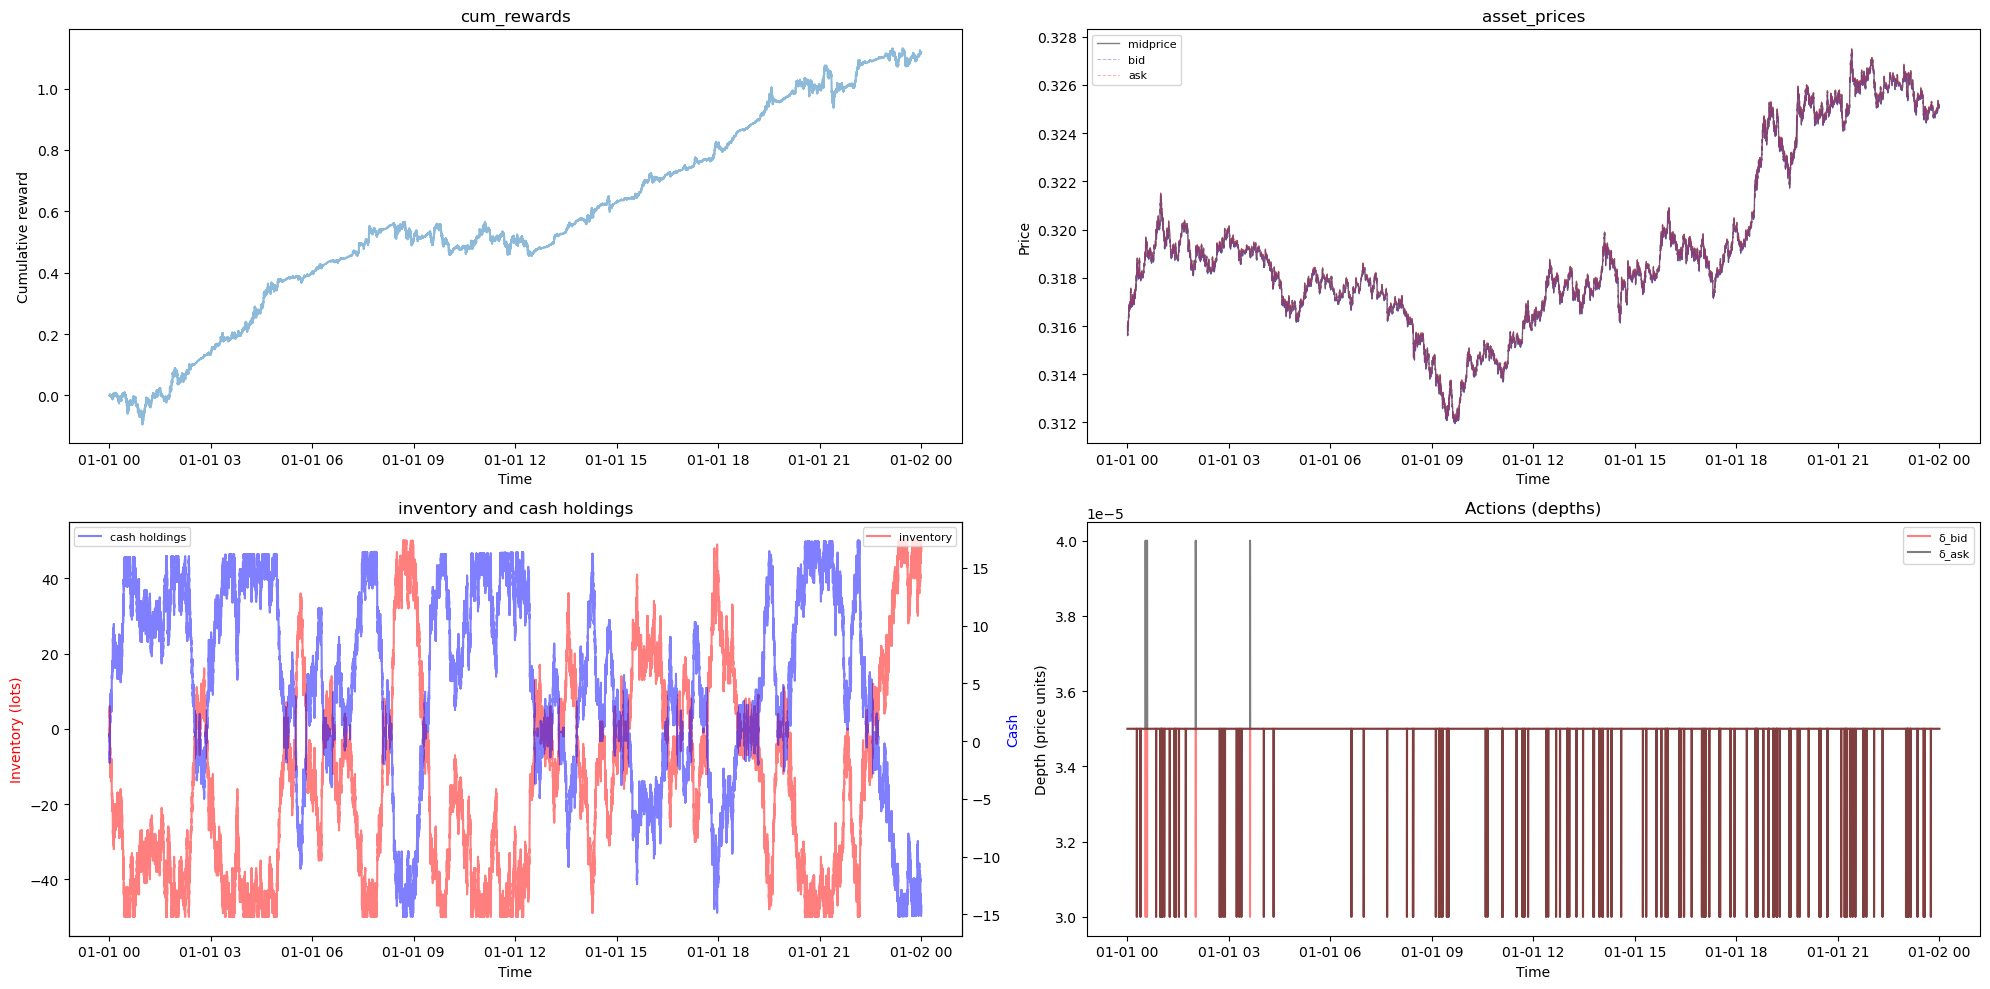

In [11]:
as_agent = AvellanedaStoikovAgent(0.001, sigma, kappa, T_sec, tick)

# Single trajectory with timestamps
env_as = TradingEnvironment(
    model_dynamics=LimitOrderModelDynamics(
        midprice_model=MarketReplayMidpriceModel(S, dt_sec, 1),
        arrival_model=PoissonArrivalModel(np.array([A, A]), 1, use_linear_approximation=False),
        fill_probability_model=ExponentialFillFunction(kappa, 1),
    ),
    reward_function=PnLReward(), max_inventory=Q_MAX,
)
plot_trajectory(env_as, as_agent, seed=42, datetime_index=dt_index)